In [1]:
import numpy as np 
import torch, torchvision
import torch.nn as nn 
import torch.optim as optim 
import torchvision.transforms as transforms 
import torch.nn.functional as F 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt 

In [2]:
torch.manual_seed(20)

In [3]:
if torch.cuda.is_available():
    device = 'cuda'
    print('cuda available')
else:
    device = 'cpu'
    print('only CPU available')

cuda available


In [4]:
train_batch = 16
test_batch = 16

In [5]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor()) 
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor()) 

In [6]:
mean = train_set.data.float().mean() 
std = train_set.data.float().std() 

In [7]:
tform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[mean/255.0], std=[std/255.0])
])

In [8]:
train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=tform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=tform) 

In [9]:
train_loader = DataLoader(train_set, batch_size=train_batch, shuffle=True)
test_loader = DataLoader(test_set, batch_size=test_batch, shuffle=True)

In [10]:
example_data, example_label = next(iter(train_loader)) 

In [11]:
example_data = example_data.to(device)

In [12]:
class CNN(nn.Module):
    def __init__(self, in_channel, hidden_dim, out_channel, bias=True):
        super().__init__() 
        self.conv1 = nn.Conv2d(in_channel, hidden_dim, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.dropout = nn.Dropout2d(p=0.5)
        self.conv2 = nn.Conv2d(hidden_dim, out_channel, kernel_size=5)
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.linear = nn.Linear(320, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        x = self.dropout(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x) 
        # print(x.shape)
        x = self.linear(x.view(x.shape[0], -1))
        x = F.relu(x)
        return x 

In [13]:
model = CNN(1, 50, 20).to(device)
model 

CNN(
  (conv1): Conv2d(1, 50, kernel_size=(5, 5), stride=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout2d(p=0.5, inplace=False)
  (conv2): Conv2d(50, 20, kernel_size=(5, 5), stride=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (linear): Linear(in_features=320, out_features=10, bias=True)
)

In [14]:
logits = model(example_data) 

In [15]:
logits.shape 

torch.Size([16, 10])

In [16]:
logits.cpu().detach().argmax(axis=1)

tensor([9, 7, 3, 6, 7, 3, 7, 7, 1, 7, 1, 7, 3, 9, 3, 6])

In [17]:
learning_rate = 1e-3
optimizer = optim.SGD(params=model.parameters(), lr=learning_rate)

In [18]:
train_loss = [] 
test_loss = []
train_acc = []
test_acc = [] 

In [20]:
n_epochs = 200 
loss_fn = F.cross_entropy 

In [21]:
def train():
    model.train()

    running_loss = 0
    running_acc = 0 
    for data, label in train_loader:
        data, label = data.to(device), label.to(device)

        logits = model(data)
        loss = loss_fn(logits, label) 
        running_loss += loss.item() 
        running_acc += (label == logits.argmax(axis=1)).sum() 

        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 

    train_loss.append(running_loss / len(train_set))
    train_acc.append(running_acc / len(train_set))

In [22]:
def test():
    model.eval() 

    running_loss = 0
    running_acc = 0 
    with torch.no_grad():
        for data, label in test_loader:
            data, label = data.to(device), label.to(device)
    
            logits = model(data)
            loss = loss_fn(logits, label)
            running_loss += loss.item() 
            running_acc += (label == logits.argmax(axis=1)).sum() 

        test_loss.append(running_loss / len(test_set))
        test_acc.append(running_acc / len(test_set))

In [23]:
for i in range(n_epochs):
    train()
    test()

    if np.mod(i, 10) == 0:
        print(f'epoch {i}, train loss: {train_loss[-1]}, train acc: {train_acc[-1]}, test loss: {test_loss[-1]}, test acc: {test_acc[-1]}')

epoch 0, train loss: 0.09104762649585803, train acc: 0.5458833575248718, test loss: 0.06789917171895504, test acc: 0.6669999957084656
epoch 10, train loss: 0.034181751690640035, train acc: 0.8709499835968018, test loss: 0.03341506234542467, test acc: 0.8728999495506287
epoch 20, train loss: 0.004410286715446758, train acc: 0.9797500371932983, test loss: 0.003313334683550056, test acc: 0.983299970626831
epoch 30, train loss: 0.00314577964965841, train acc: 0.9848166704177856, test loss: 0.0026297753660110175, test acc: 0.9860000014305115
epoch 40, train loss: 0.002605537368968847, train acc: 0.9876000285148621, test loss: 0.002393777412721829, test acc: 0.9860999584197998
epoch 50, train loss: 0.0022234949255094763, train acc: 0.9895166754722595, test loss: 0.0022878763385619093, test acc: 0.9868999719619751
epoch 60, train loss: 0.0019597943486898656, train acc: 0.9904333353042603, test loss: 0.0023086631501006197, test acc: 0.9872999787330627
epoch 70, train loss: 0.001737723344617491

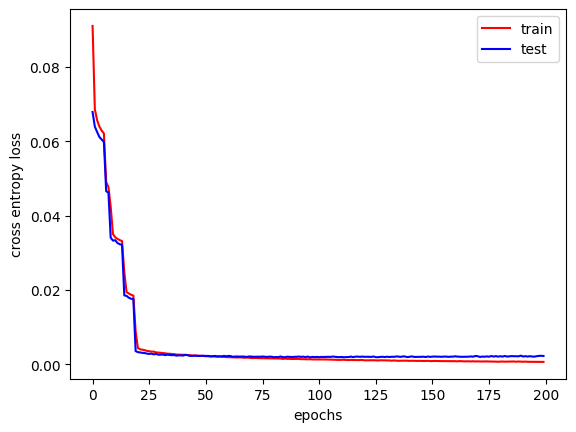

In [28]:
plt.figure()
plt.plot(train_loss, color='r', label='train')
plt.plot(test_loss, color='b', label='test')
plt.xlabel('epochs')
plt.ylabel('cross entropy loss') 
plt.legend()

In [26]:
train_acc = [x.cpu().detach() for x in train_acc]
test_acc = [x.cpu().detach() for x in test_acc] 

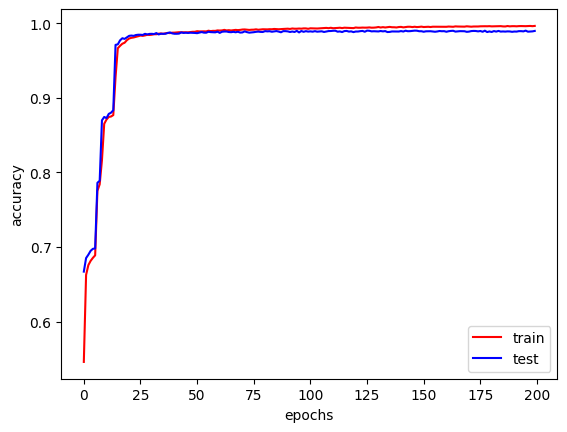

In [29]:
plt.figure()
plt.plot(train_acc, color='r', label='train')
plt.plot(test_acc, color='b', label='test')
plt.xlabel('epochs')
plt.ylabel('accuracy') 
plt.legend() 